## 1. THU THẬP DỮ LIỆU (DATA COLLECTION)

Sử dụng kỹ thuật Web Crawling để thu thập dữ liệu từ bonbanh.com

In [1]:
import requests
from bs4 import BeautifulSoup
import csv
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [2]:
class BonbanhCrawler:
    """Crawler để thu thập dữ liệu thô từ bonbanh.com"""
    BASE_URL = "https://bonbanh.com"
    TIMEOUT = 15
    DELAY_BETWEEN_CARS = 0.5
    DELAY_BETWEEN_PAGES = 3
    
    def __init__(self):
        self.base_url = self.BASE_URL
        self.headers = self._get_headers()
        self.cars_data = []
    
    @staticmethod
    def _get_headers() -> Dict[str, str]:
        return {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
            'Accept-Language': 'vi-VN,vi;q=0.9,en-US;q=0.8,en;q=0.7',
            'Connection': 'keep-alive',
        }
    
    @staticmethod
    def _clean_text(text: str) -> str:
        """Làm sạch text: xóa khoảng trắng thừa, tab, newline"""
        if not text:
            return ''
        # Chuyển tất cả whitespace thành space đơn
        text = re.sub(r'\s+', ' ', str(text))
        return text.strip()
    
    @staticmethod
    def _clean_km_value(km_str: str) -> str:
        """Xóa dấu phẩy trong số km"""
        if not km_str:
            return ''
        return km_str.replace(',', '').strip()
    
    @staticmethod
    def _remove_price_from_name(name: str) -> str:
        """Tách tên xe tại dấu '-' để loại bỏ giá"""
        if not name or '-' not in name:
            return name
        # Tách tại dấu '-' đầu tiên và lấy phần trước
        parts = name.split('-', 1)
        return parts[0].strip()
    
    @staticmethod
    def _clean_fuel_value(fuel_str: str) -> str:
        """Làm sạch giá trị nhiên liệu: loại bỏ dung tích (số L)"""
        if not fuel_str:
            return ''
        # Loại bỏ dung tích như "1.5L", "2.0 L", etc.
        fuel = re.sub(r'\s*\d+\.?\d*\s*[Ll].*$', '', fuel_str)
        return fuel.strip()
    
    def get_page_content(self, url: str) -> Optional[str]:
        """Lấy nội dung HTML từ URL"""
        try:
            response = requests.get(url, headers=self.headers, timeout=self.TIMEOUT)
            response.encoding = 'utf-8'
            if response.status_code == 200:
                return response.text
            return None
        except:
            return None
    
    def extract_car_name(self, soup: BeautifulSoup) -> str:
        """Trích xuất tên xe và loại bỏ giá"""
        try:
            h1_tag = soup.find('h1')
            if h1_tag:
                name = self._clean_text(h1_tag.get_text())
                # Loại bỏ phần giá (sau dấu '-')
                name = self._remove_price_from_name(name)
                return name
            return ''
        except:
            return ''
    
    def extract_price(self, soup: BeautifulSoup) -> str:
        """Trích xuất giá xe (thô - chưa xử lý)"""
        try:
            price_elem = soup.find('b', string=lambda text: text and ('Triệu' in text or 'Tỷ' in text))
            if price_elem:
                return self._clean_text(price_elem.get_text())
            
            h1_tag = soup.find('h1')
            if h1_tag:
                h1_text = h1_tag.get_text()
                price_match = re.search(r'(\d+(?:\.\d+)?)\s*(Triệu|Tỷ)', h1_text)
                if price_match:
                    return price_match.group(0)
            
            return ''
        except:
            return ''
    
    def extract_value_after_label(self, soup: BeautifulSoup, label_keywords: List[str]) -> str:
        """Trích xuất giá trị sau label"""
        for label in soup.find_all('label'):
            label_text = label.get_text(strip=True)
            
            if not any(keyword in label_text for keyword in label_keywords):
                continue
            
            inp = label.find_next('span', class_='inp')
            if inp:
                return self._clean_text(inp.get_text())
            
            row = label.find_parent('div', class_='row')
            if row:
                inp = row.find('span', class_='inp')
                if inp:
                    return self._clean_text(inp.get_text())
            
            parent = label.find_parent('div')
            if parent:
                all_text = parent.get_text(strip=True)
                parts = all_text.split(label_text)
                if len(parts) > 1:
                    remaining = parts[1]
                    next_label = label.find_next('label')
                    if next_label:
                        next_label_text = next_label.get_text(strip=True)
                        remaining = remaining.split(next_label_text)[0]
                    return remaining.strip()
        
        return ''
    
    def parse_detail_page(self, url: str) -> Optional[Dict[str, str]]:
        """Parse trang chi tiết xe - lấy dữ liệu thô"""
        html = self.get_page_content(url)
        if not html:
            return None
        
        soup = BeautifulSoup(html, 'html.parser')
        
        car_info = {
            'Ngày đăng bài': '',
            'Năm SX': '',
            'Tên xe': '',
            'Giá': '',
            'Xuất xứ': '',
            'Địa điểm': '',
            'Kiểu dáng': '',
            'Số km đã đi': '',
            'Hộp số': '',
            'Tình trạng': '',
            'Nhiên liệu': ''
        }
        
        try:
            car_info['Tên xe'] = self.extract_car_name(soup)
            car_info['Giá'] = self.extract_price(soup)
            self._parse_car_specs(soup, car_info)
            self._parse_postdate(soup, car_info)
        except:
            pass
        
        return car_info
    
    def _parse_car_specs(self, soup: BeautifulSoup, car_info: Dict[str, str]) -> None:
        """Parse thông số kỹ thuật xe"""
        rows = soup.find_all('div', class_='row')
        
        for row in rows:
            label = row.find('label')
            inp = row.find('span', class_='inp')
            
            if not (label and inp):
                continue
            
            label_text = label.get_text(strip=True)
            value = self._clean_text(inp.get_text())
            
            if 'Năm sản xuất' in label_text:
                car_info['Năm SX'] = value
            elif 'Xuất xứ' in label_text:
                car_info['Xuất xứ'] = value
            elif 'Kiểu dáng' in label_text:
                car_info['Kiểu dáng'] = value
            elif 'Số Km' in label_text:
                car_info['Số km đã đi'] = self._clean_km_value(value)
            elif 'Hộp số' in label_text:
                car_info['Hộp số'] = value
            elif 'Động cơ' in label_text or 'Nhiên liệu' in label_text:
                car_info['Nhiên liệu'] = self._clean_fuel_value(value)
            elif 'Tình trạng' in label_text:
                car_info['Tình trạng'] = value
        
        if not car_info['Hộp số']:
            transmission = self.extract_value_after_label(soup, ['Hộp số'])
            car_info['Hộp số'] = transmission
    
    def _parse_postdate(self, soup: BeautifulSoup, car_info: Dict[str, str]) -> None:
        """Parse ngày đăng bài"""
        notes_div = soup.find('div', class_='notes')
        if notes_div:
            notes_text = notes_div.get_text()
            match = re.search(r'Đăng ngày\s+(\d+/\d+/\d+)', notes_text)
            if match:
                car_info['Ngày đăng bài'] = match.group(1)
    
    def find_car_links_with_location(self, soup: BeautifulSoup) -> List[tuple]:
        """Tìm links xe và địa điểm"""
        car_data = []
        for item in soup.find_all('li', class_='car-item'):
            link = item.find('a', href=True)
            if link:
                href = link.get('href', '')
                if href.startswith('xe-') and any(char.isdigit() for char in href):
                    full_url = f"{self.base_url}/{href}" if not href.startswith('http') else href
                    
                    location = ''
                    cb4_div = item.find('div', class_='cb4')
                    if cb4_div:
                        location_elem = cb4_div.find('b')
                        if location_elem:
                            location = location_elem.get_text(strip=True)
                    
                    car_data.append((full_url, location))
        
        seen = set()
        unique_data = []
        for url, loc in car_data:
            if url not in seen:
                seen.add(url)
                unique_data.append((url, loc))
        
        return unique_data
    
    def crawl_page(self, url: str, page_num: int = 1) -> List[Dict[str, str]]:
        """Crawl một trang"""
        html = self.get_page_content(url)
        if not html:
            return []
        
        soup = BeautifulSoup(html, 'html.parser')
        car_data = self.find_car_links_with_location(soup)
        
        cars = []
        for idx, (car_url, location) in enumerate(car_data, 1):
            car_info = self.parse_detail_page(car_url)
            
            if car_info and car_info['Tên xe']:
                if location:
                    car_info['Địa điểm'] = location
                cars.append(car_info)
                print(f"  ✅ [{idx:2d}] {car_info['Tên xe']}")
            
            time.sleep(self.DELAY_BETWEEN_CARS)
        
        return cars
    
    def crawl_multiple_pages(self, num_pages: int = 200) -> List[Dict[str, str]]:
        """Crawl nhiều trang"""
        all_cars = []
        for page in range(1, num_pages + 1):
            url = f"{self.base_url}/oto" if page == 1 else f"{self.base_url}/oto/page,{page}"
            print(f"📄 Crawling page {page}/{num_pages}...")
            cars = self.crawl_page(url, page)
            all_cars.extend(cars)
            if page < num_pages:
                time.sleep(self.DELAY_BETWEEN_PAGES)
        
        self.cars_data = all_cars
        return all_cars
    
    def save_to_csv(self, filename: str = 'bonbanh_data.csv') -> Optional[str]:
        """Lưu dữ liệu thô vào CSV"""
        if not self.cars_data:
            return None
        
        fields = [
            'Ngày đăng bài', 'Năm SX', 'Tên xe', 'Giá', 'Xuất xứ', 'Địa điểm',
            'Kiểu dáng', 'Số km đã đi', 'Hộp số', 'Tình trạng', 'Nhiên liệu'
        ]
        
        try:
            with open(filename, 'w', newline='', encoding='utf-8-sig') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=fields)
                writer.writeheader()
                for car in self.cars_data:
                    writer.writerow(car)
            return filename
        except:
            return None

In [3]:
# Khởi tạo crawler và bắt đầu thu thập dữ liệu
crawler = BonbanhCrawler()
start_time = time.time()

# Thu thập dữ liệu từ 500 trang đầu tiên (có thể thay đổi số trang)
print("🚀 Bắt đầu thu thập dữ liệu...\n")
cars_data = crawler.crawl_multiple_pages(num_pages=500)

end_time = time.time()
elapsed_time = int(end_time - start_time)

print(f"\n{'='*60}")
print(f"✅ HOÀN TẤT THU THẬP DỮ LIỆU")
print(f"⏱️  Thời gian: {elapsed_time}s")
print(f"📊 Tổng số xe thu thập: {len(cars_data)}")
print(f"{'='*60}")

🚀 Bắt đầu thu thập dữ liệu...

📄 Crawling page 1/500...
  ✅ [ 1] Xe Mercedes Benz C class C200 2018
  ✅ [ 2] Xe Lexus LX 600 Vip 2025
  ✅ [ 3] Xe VinFast VF6 Plus 2024
  ✅ [ 4] Xe VinFast VF6 Plus 2024
  ✅ [ 5] Xe Hyundai Tucson 2.0 AT Tiêu chuẩn 2021
  ✅ [ 6] Xe Kia Morning Luxury 2019
  ✅ [ 7] Xe Audi Q2 1.4 TFSI 2019
  ✅ [ 8] Xe Hyundai Stargazer X 1.5 AT 2024
  ✅ [ 9] Xe Mercedes Benz GLC 300 4Matic 2020
  ✅ [10] Xe Honda Jazz RS 2019
  ✅ [11] Xe Kia Rio 1.4 AT 2015
  ✅ [12] Xe Mitsubishi Outlander 2.0 CVT 2022
  ✅ [13] Xe Mazda 3 1.5L Luxury 2023
  ✅ [14] Xe Hyundai Accent Cao cấp 1.5 AT 2024
  ✅ [15] Xe Kia Seltos Premium 1.6 AT 2022
  ✅ [16] Xe Ford Everest Titanium Plus 2.0L 4x4 AT 2024
  ✅ [17] Xe Nissan Almera VL 1.0 CVT Cao cấp 2022
  ✅ [18] Xe Mazda 6 2.0 AT 2012
  ✅ [19] Xe Kia Sorento GAT 2017
  ✅ [20] Xe Lexus RX 350 2016
📄 Crawling page 2/500...
  ✅ [ 1] Xe Lexus LX 570 2015
  ✅ [ 2] Xe Ford Everest Titanium 2.0L 4x2 AT 2023
  ✅ [ 3] Xe Lexus LX 570 2015
  ✅ [ 4] Xe Hyu

## 2. HIỂN THỊ VÀ KHÁM PHÁ DỮ LIỆU

Tạo DataFrame và khám phá dữ liệu ban đầu

In [49]:
df = pd.DataFrame(cars_data)

print("📊 THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU\n")
print(f"Số lượng dòng: {len(df)}")
print(f"Số lượng cột: {len(df.columns)}")
print(f"\nDanh sách các cột:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📊 THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU

Số lượng dòng: 10000
Số lượng cột: 11

Danh sách các cột:
  1. Ngày đăng bài
  2. Năm SX
  3. Tên xe
  4. Giá
  5. Xuất xứ
  6. Địa điểm
  7. Kiểu dáng
  8. Số km đã đi
  9. Hộp số
  10. Tình trạng
  11. Nhiên liệu


In [5]:
df.head()

,Ngày đăng bài,Năm SX,Tên xe,Giá,Xuất xứ,Địa điểm,Kiểu dáng,Số km đã đi,Hộp số,Tình trạng,Nhiên liệu
0,23/10/2025,2018,Xe Mercedes Benz C class C200 2018,739 Triệu,Lắp ráp trong nước,TP HCM,Sedan,69000 Km,Số tự động,Xe đã dùng,Xăng
1,23/10/2025,2025,Xe Lexus LX 600 Vip 2025,9 Tỷ,Nhập khẩu,Hà Nội,SUV,,Số tự động,Xe mới,Xăng
2,23/10/2025,2024,Xe VinFast VF6 Plus 2024,640 Triệu,Lắp ráp trong nước,Hà Nội,SUV,29000 Km,Số tự động,Xe đã dùng,Điện
3,23/10/2025,2024,Xe VinFast VF6 Plus 2024,640 Triệu,Lắp ráp trong nước,Hà Nội,SUV,28000 Km,Số tự động,Xe đã dùng,Điện
4,23/10/2025,2021,Xe Hyundai Tucson 2.0 AT Tiêu chuẩn 2021,635 Triệu,Lắp ráp trong nước,Hà Nội,Crossover,47000 Km,Số tự động,Xe đã dùng,Xăng


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Ngày đăng bài  10000 non-null  object
 1   Năm SX         10000 non-null  object
 2   Tên xe         10000 non-null  object
 3   Giá            10000 non-null  object
 4   Xuất xứ        10000 non-null  object
 5   Địa điểm       10000 non-null  object
 6   Kiểu dáng      10000 non-null  object
 7   Số km đã đi    10000 non-null  object
 8   Hộp số         10000 non-null  object
 9   Tình trạng     10000 non-null  object
 10  Nhiên liệu     10000 non-null  object
dtypes: object(11)
memory usage: 859.5+ KB


In [51]:
df.describe(include='object')

,Ngày đăng bài,Năm SX,Tên xe,Giá,Xuất xứ,Địa điểm,Kiểu dáng,Số km đã đi,Hộp số,Tình trạng,Nhiên liệu
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,1,32,2767,654,2,50,10,707,2,2,4
top,23/10/2025,2025,Xe Toyota Land Cruiser 3.5 V6 2025,1 Tỷ,Lắp ráp trong nước,Hà Nội,SUV,,Số tự động,Xe đã dùng,Xăng
freq,10000,2226,92,1911,5145,6329,4699,2279,9353,7721,7536


## 3. LƯU DỮ LIỆU THÔ VÀO FILE CSV

In [52]:
import os

csv_file = crawler.save_to_csv('bonbanh_data_raw.csv')

if csv_file:
    print(f"✅ Đã lưu: {csv_file}")
    print(f"📁 Kích thước: {os.path.getsize(csv_file) / 1024:.2f} KB")
else:
    print("❌ Không thể lưu dữ liệu")

✅ Đã lưu: bonbanh_data_raw.csv
📁 Kích thước: 1369.88 KB


## 4. LÀM SẠCH DỮ LIỆU (DATA CLEANING)

### 4.1. Kiểm tra và Đổi Kiểu Dữ Liệu

In [53]:
def handle_missing_values(value: str, default='N/A') -> str:
    """Xử lý giá trị rỗng hoặc None"""
    if pd.isna(value) or value == '' or value is None:
        return default
    return str(value).strip()

def clean_car_name(name: str) -> str:
    """Làm sạch tên xe"""
    name = handle_missing_values(name, 'N/A')
    if name == 'N/A':
        return name
    
    name = name.replace('Xe', '').strip()
    name = re.sub(r'-\s*\d+(?:\.\d+)?\s*(?:Triệu|Tỷ).*$', '', name).strip()
    name = re.sub(r'\s*20\d{2}\s*$', '', name).strip()
    name = re.sub(r'\s+', ' ', name).strip()
    return name if name else 'N/A'

def parse_price(price_str: str) -> float:
    """Chuyển đổi giá từ text sang số (VNĐ)"""
    price_str = handle_missing_values(price_str, '')
    if not price_str or price_str == 'N/A':
        return np.nan
    
    try:
        price_match = re.search(r'(\d+(?:\.\d+)?)\s*(Triệu|Tỷ)', str(price_str))
        if price_match:
            value = float(price_match.group(1))
            unit = price_match.group(2)
            if unit == 'Tỷ':
                return value * 1_000_000_000
            else:
                return value * 1_000_000
        return np.nan
    except:
        return np.nan

def clean_km(km_str: str) -> float:
    """Làm sạch số km đã đi"""
    km_str = handle_missing_values(km_str, '')
    if not km_str or km_str == 'N/A':
        return np.nan
    
    try:
        km = re.sub(r'[^\d]', '', str(km_str))
        return float(km) if km else np.nan
    except:
        return np.nan

def clean_fuel(fuel_str: str) -> str:
    """Làm sạch loại nhiên liệu - loại bỏ dung tích (số L)"""
    fuel_str = handle_missing_values(fuel_str, 'N/A')
    if fuel_str == 'N/A':
        return fuel_str
    
    # Loại bỏ dung tích (ví dụ: "Xăng 1.5L" -> "Xăng")
    fuel = re.sub(r'\s*\d+\.?\d*\s*[Ll].*$', '', str(fuel_str))
    fuel = fuel.strip()
    
    # Nếu sau khi loại bỏ còn nhiều từ, lấy từ đầu tiên
    if ' ' in fuel:
        fuel = fuel.split()[0]
    
    return fuel if fuel else 'N/A'

def clean_year(year_str: str) -> int:
    """Làm sạch năm sản xuất"""
    year_str = handle_missing_values(year_str, '')
    if not year_str or year_str == 'N/A':
        return np.nan
    
    try:
        return int(re.sub(r'[^\d]', '', str(year_str)))
    except:
        return np.nan

df_clean = df.copy()

In [54]:
print("\n📋 BƯỚC 1: XỬ LÝ GIÁ TRỊ RỖNG VÀ CHUẨN HÓA\n")

# Thay thế giá trị rỗng bằng N/A
for col in df_clean.columns:
    df_clean[col] = df_clean[col].apply(lambda x: handle_missing_values(x, 'N/A'))

print(f"Đã xử lý giá trị rỗng cho {len(df_clean.columns)} cột")
print(f"   Tổng số dòng: {len(df_clean)}")


📋 BƯỚC 1: XỬ LÝ GIÁ TRỊ RỖNG VÀ CHUẨN HÓA

Đã xử lý giá trị rỗng cho 11 cột
   Tổng số dòng: 10000


In [ ]:
print("\n📋 BƯỚC 2: LÀM SẠCH VÀ CHUYỂN ĐỔI DỮ LIỆU\n")
# 1. Làm sạch tên xe
df_clean['Tên xe'] = df_clean['Tên xe'].apply(clean_car_name)
print("Làm sạch 'Tên xe'")

# 2. Chuyển đổi giá
df_clean['Giá'] = df_clean['Giá'].apply(parse_price)
valid_price = df_clean['Giá'].notna().sum()
print(f"Chuyển đổi 'Giá': {valid_price}/{len(df_clean)} giá trị hợp lệ")

# 3. Làm sạch số km
df_clean['Số km đã đi'] = df_clean['Số km đã đi'].apply(clean_km)
valid_km = df_clean['Số km đã đi'].notna().sum()
print(f"Làm sạch 'Số km đã đi': {valid_km}/{len(df_clean)} giá trị hợp lệ")

# 4. Chuyển đổi năm SX
df_clean['Năm SX'] = df_clean['Năm SX'].apply(clean_year)
df_clean['Năm SX'] = df_clean['Năm SX'].astype('Int64')
valid_year = df_clean['Năm SX'].notna().sum()
print(f"Chuyển đổi 'Năm SX': {valid_year}/{len(df_clean)} giá trị hợp lệ")

# 5. Làm sạch nhiên liệu
df_clean['Nhiên liệu'] = df_clean['Nhiên liệu'].apply(clean_fuel)
print("Làm sạch 'Nhiên liệu'")

# 6. Chuyển đổi ngày đăng bài
df_clean['Ngày đăng bài'] = df_clean['Ngày đăng bài'].replace('N/A', np.nan)
df_clean['Ngày đăng bài'] = pd.to_datetime(
    df_clean['Ngày đăng bài'], 
    format='%d/%m/%Y', 
    errors='coerce'
)
valid_date = df_clean['Ngày đăng bài'].notna().sum()
print(f"Chuyển đổi 'Ngày đăng bài': {valid_date}/{len(df_clean)} giá trị hợp lệ")


📋 BƯỚC 2: LÀM SẠCH VÀ CHUYỂN ĐỔI DỮ LIỆU

Làm sạch 'Tên xe'
Chuyển đổi 'Giá': 10000/10000 giá trị hợp lệ
Làm sạch 'Số km đã đi': 7721/10000 giá trị hợp lệ
Chuyển đổi 'Năm SX': 10000/10000 giá trị hợp lệ
Làm sạch 'Nhiên liệu'
Chuyển đổi 'Ngày đăng bài': 10000/10000 giá trị hợp lệ


In [56]:
print("\nBƯỚC 3: THỐNG KÊ SAU LÀM SẠCH\n")

print(f"Giá:")
print(f"   • Giá trị hợp lệ: {df_clean['Giá'].notna().sum()}/{len(df_clean)}")
print(f"   • Trung bình: {df_clean['Giá'].mean():,.0f} VNĐ")
print(f"   • Min-Max: {df_clean['Giá'].min():,.0f} - {df_clean['Giá'].max():,.0f} VNĐ")

print(f"\nSố km đã đi:")
print(f"   • Giá trị hợp lệ: {df_clean['Số km đã đi'].notna().sum()}/{len(df_clean)}")
print(f"   • Trung bình: {df_clean['Số km đã đi'].mean():,.0f} km")

print(f"\nNăm SX:")
print(f"   • Giá trị hợp lệ: {df_clean['Năm SX'].notna().sum()}/{len(df_clean)}")
print(f"   • Phạm vi: {int(df_clean['Năm SX'].min())} - {int(df_clean['Năm SX'].max())}")


BƯỚC 3: THỐNG KÊ SAU LÀM SẠCH

Giá:
   • Giá trị hợp lệ: 10000/10000
   • Trung bình: 1,193,856,300 VNĐ
   • Min-Max: 29,000,000 - 28,000,000,000 VNĐ

Số km đã đi:
   • Giá trị hợp lệ: 7721/10000
   • Trung bình: 56,656 km

Năm SX:
   • Giá trị hợp lệ: 10000/10000
   • Phạm vi: 1989 - 2025


In [57]:
print("\n🔍 KIỂM TRA TRÙNG LẶP\n")
duplicates = df_clean.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")

if duplicates > 0:
    print(f"\nXóa {duplicates} dòng trùng lặp...")
    df_clean = df_clean.drop_duplicates()
    print(f"✓ Còn lại: {len(df_clean)} dòng duy nhất")


🔍 KIỂM TRA TRÙNG LẶP

Số dòng trùng lặp: 1963

Xóa 1963 dòng trùng lặp...
✓ Còn lại: 8037 dòng duy nhất


### 4.2. Xử Lý Giá Trị Trùng Lặp

In [58]:
print("\n4.2. XỬ LÝ GIÁ TRỊ TRÙNG LẶP\n")

duplicates_all = df_clean.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {duplicates_all}")

key_cols = ['Tên xe', 'Năm SX', 'Giá', 'Số km đã đi']
duplicates_key = df_clean.duplicated(subset=key_cols, keep='first').sum()
print(f"Số dòng trùng lặp theo key: {duplicates_key}")

if duplicates_key > 0:
    df_clean = df_clean.drop_duplicates(subset=key_cols, keep='first')
    print(f"Đã xóa {duplicates_key} dòng trùng lặp")
else:
    print("Không có dòng trùng lặp")


4.2. XỬ LÝ GIÁ TRỊ TRÙNG LẶP

Số dòng trùng lặp hoàn toàn: 0
Số dòng trùng lặp theo key: 294
Đã xóa 294 dòng trùng lặp


### 4.3. Format Lại Các Cột Categorical

In [59]:
print("\n4.3. FORMAT CÁC CỘT CATEGORICAL\n")

categorical_cols = ['Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Tình trạng', 'Nhiên liệu']

for col in categorical_cols:
    print(f"{col}: {df_clean[col].nunique()} giá trị unique")


4.3. FORMAT CÁC CỘT CATEGORICAL

Xuất xứ: 2 giá trị unique
Kiểu dáng: 10 giá trị unique
Hộp số: 2 giá trị unique
Tình trạng: 2 giá trị unique
Nhiên liệu: 4 giá trị unique


In [60]:
# Kiểm tra giá trị unique trong cột Xuất xứ
print("Giá trị unique trong 'Xuất xứ' TRƯỚC khi chuẩn hóa:")
print(df_clean['Xuất xứ'].unique())
print(f"\nSố lượng: {df_clean['Xuất xứ'].value_counts()}\n")

# Chuẩn hóa cột Xuất xứ
df_clean['Xuất xứ'] = df_clean['Xuất xứ'].str.strip().str.title()

# Mapping cho xuất xứ (theo dữ liệu thực tế từ bonbanh.com)
origin_mapping = {
    'Lắp Ráp Trong Nước': 'Nội địa',
    'Nhập Khẩu': 'Nhập khẩu',
    'Việt Nam': 'Việt Nam',
    'Viet Nam': 'Việt Nam',
    'VN': 'Việt Nam'
}

df_clean['Xuất xứ'] = df_clean['Xuất xứ'].replace(origin_mapping)

print("Giá trị unique SAU khi chuẩn hóa:")
print(df_clean['Xuất xứ'].unique())
print(f"\n{df_clean['Xuất xứ'].value_counts()}")
print(f"\n✅ Chuẩn hóa 'Xuất xứ'")

Giá trị unique trong 'Xuất xứ' TRƯỚC khi chuẩn hóa:
['Lắp ráp trong nước' 'Nhập khẩu']

Số lượng: Xuất xứ
Lắp ráp trong nước    4224
Nhập khẩu             3519
Name: count, dtype: int64

Giá trị unique SAU khi chuẩn hóa:
['Nội địa' 'Nhập khẩu']

Xuất xứ
Nội địa      4224
Nhập khẩu    3519
Name: count, dtype: int64

✅ Chuẩn hóa 'Xuất xứ'


In [17]:
df_clean['Hộp số'] = df_clean['Hộp số'].str.strip().str.title()
transmission_mapping = {
    'Số Tự Động': 'Tự động',
    'Tự Động': 'Tự động',
    'Automatic': 'Tự động',
    'Số Sàn': 'Số sàn',
    'Sàn': 'Số sàn',
    'Manual': 'Số sàn'
}
df_clean['Hộp số'] = df_clean['Hộp số'].replace(transmission_mapping)
print(f"✅ Chuẩn hóa 'Hộp số'")

✅ Chuẩn hóa 'Hộp số'


In [61]:
# Tách loại nhiên liệu từ chuỗi chứa dung tích (ví dụ: "Xăng 1.5L" -> "Xăng")
df_clean['Nhiên liệu'] = df_clean['Nhiên liệu'].str.strip().str.title()

# Loại bỏ dung tích (số + L/l) và khoảng trắng thừa
df_clean['Nhiên liệu'] = df_clean['Nhiên liệu'].str.replace(r'\s*\d+\.?\d*\s*L.*$', '', regex=True, case=False)
df_clean['Nhiên liệu'] = df_clean['Nhiên liệu'].str.strip()

fuel_mapping = {
    'Xăng': 'Xăng',
    'Gasoline': 'Xăng',
    'Petrol': 'Xăng',
    'Dầu': 'Dầu diesel',
    'Diesel': 'Dầu diesel',
    'Điện': 'Điện',
    'Electric': 'Điện',
    'Hybrid': 'Hybrid'
}
df_clean['Nhiên liệu'] = df_clean['Nhiên liệu'].replace(fuel_mapping)

print("Giá trị unique SAU khi chuẩn hóa:")
print(df_clean['Nhiên liệu'].unique())
print(f"\n{df_clean['Nhiên liệu'].value_counts()}")
print(f"\n✅ Chuẩn hóa 'Nhiên liệu'")

Giá trị unique SAU khi chuẩn hóa:
['Xăng' 'Điện' 'Dầu diesel' 'Hybrid']

Nhiên liệu
Xăng          6078
Dầu diesel    1121
Điện           326
Hybrid         218
Name: count, dtype: int64

✅ Chuẩn hóa 'Nhiên liệu'


In [19]:
df_clean['Tình trạng'] = df_clean['Tình trạng'].str.strip().str.title()
condition_mapping = {
    'Đã Qua Sử Dụng': 'Đã sử dụng',
    'Đã Sử Dụng': 'Đã sử dụng',
    'Xe Đã Dùng': 'Đã sử dụng',
    'Used': 'Đã sử dụng',
    'Cũ': 'Đã sử dụng',
    'Xe Mới': 'Xe mới',
    'Mới': 'Xe mới',
    'New': 'Xe mới'
}
df_clean['Tình trạng'] = df_clean['Tình trạng'].replace(condition_mapping)
print(f"✅ Chuẩn hóa 'Tình trạng'")

✅ Chuẩn hóa 'Tình trạng'


In [20]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')
print("✅ Chuyển sang kiểu category")

✅ Chuyển sang kiểu category


### 4.4. Xử Lý Giá Trị Khuyết Thiếu (Missing Values)

Áp dụng các phương pháp từ bài giảng:
- Loại bỏ nếu < 3%
- Thay thế bằng mean/median/mode
- Sử dụng nội suy

In [2]:
print("\n🔍 4.4. XỬ LÝ GIÁ TRỊ KHUYẾT THIẾU\n")

missing_count = df_clean.isnull().sum()
missing_percent = (missing_count / len(df_clean)) * 100

missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ (%)': missing_percent
}).sort_values('Tỷ lệ (%)', ascending=False)

print(missing_df[missing_df['Số lượng thiếu'] > 0])


🔍 4.4. XỬ LÝ GIÁ TRỊ KHUYẾT THIẾU



NameError: name 'df_clean' is not defined

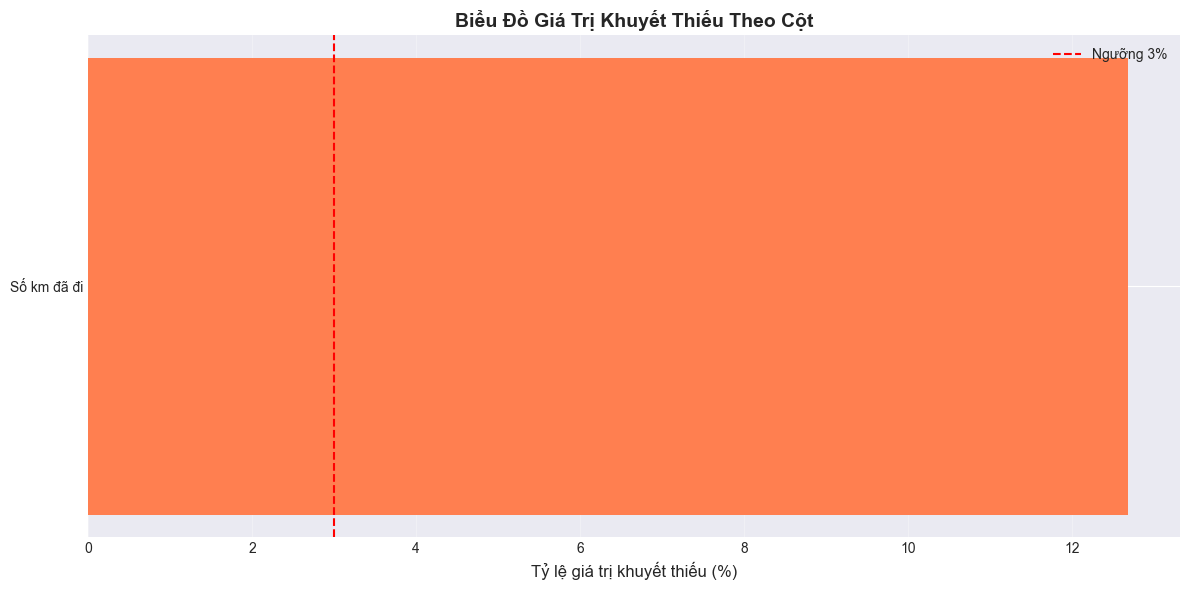

In [ ]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_data = missing_df[missing_df['Số lượng thiếu'] > 0]
if len(missing_data) > 0:
    plt.barh(missing_data.index, missing_data['Tỷ lệ (%)'], color='coral')
    plt.xlabel('Tỷ lệ giá trị khuyết thiếu (%)', fontsize=12)
    plt.title('Biểu Đồ Giá Trị Khuyết Thiếu Theo Cột', fontsize=14, fontweight='bold')
    plt.axvline(x=3, color='red', linestyle='--', label='Ngưỡng 3%')
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("✅ Không có giá trị khuyết thiếu")

In [ ]:
print("\n🔧 ÁP DỤNG CHIẾN LƯỢC XỬ LÝ:\n")

important_cols = ['Tên xe', 'Giá', 'Năm SX']
before_count = len(df_clean)
df_clean = df_clean.dropna(subset=important_cols, how='any')
after_count = len(df_clean)
removed = before_count - after_count
print(f"1️⃣ Loại bỏ {removed} dòng thiếu thông tin quan trọng")


🔧 ÁP DỤNG CHIẾN LƯỢC XỬ LÝ:

1️⃣ Loại bỏ 0 dòng thiếu thông tin quan trọng


In [ ]:
print("2️⃣ Xử lý 'Số km đã đi'...")

df_clean.loc[
    (df_clean['Số km đã đi'].isnull()) & (df_clean['Tình trạng'] == 'Xe mới'), 
    'Số km đã đi'
] = 0

for year in df_clean['Năm SX'].unique():
    if pd.notna(year):
        median_km = df_clean[
            (df_clean['Năm SX'] == year) & 
            (df_clean['Số km đã đi'].notna())
        ]['Số km đã đi'].median()
        
        if pd.notna(median_km):
            df_clean.loc[
                (df_clean['Năm SX'] == year) & 
                (df_clean['Số km đã đi'].isnull()),
                'Số km đã đi'
            ] = median_km

overall_median = df_clean['Số km đã đi'].median()
df_clean['Số km đã đi'].fillna(overall_median, inplace=True)
print(f"   ✅ Đã điền median ({overall_median:,.0f} km)")

2️⃣ Xử lý 'Số km đã đi'...
   ✅ Đã điền median (42,000 km)


In [ ]:
print("3️⃣ Xử lý categorical...")

categorical_to_fill = ['Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Nhiên liệu', 'Địa điểm']

for col in categorical_to_fill:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Không xác định'
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"   ✅ {col}: mode = '{mode_value}'")

3️⃣ Xử lý categorical...


In [ ]:
print("4️⃣ Xử lý 'Tình trạng'...")

df_clean['Tình trạng'] = df_clean['Tình trạng'].astype('object')

df_clean.loc[
    (df_clean['Tình trạng'].isnull()) & (df_clean['Số km đã đi'] == 0),
    'Tình trạng'
] = 'Xe mới'

df_clean.loc[
    (df_clean['Tình trạng'].isnull()) & (df_clean['Số km đã đi'] > 0),
    'Tình trạng'
] = 'Đã sử dụng'

df_clean['Tình trạng'] = df_clean['Tình trạng'].astype('category')

print("   ✅ Suy luận từ số km đã đi")

4️⃣ Xử lý 'Tình trạng'...
   ✅ Suy luận từ số km đã đi


In [ ]:
print("\n✅ KẾT QUẢ SAU XỬ LÝ:\n")
missing_after = df_clean.isnull().sum()
print(missing_after[missing_after > 0] if any(missing_after > 0) else "Không còn giá trị khuyết thiếu!")
print(f"\n📊 Tổng số dòng: {len(df_clean)}")


✅ KẾT QUẢ SAU XỬ LÝ:

Không còn giá trị khuyết thiếu!

📊 Tổng số dòng: 7743


### 4.5. Phát Hiện và Xử Lý Giá Trị Ngoại Lai (Outliers)

Áp dụng 2 phương pháp:
1. **Box Plot Method**: IQR = Q3 - Q1
2. **Statistical Method**: Mean ± 2σ hoặc ± 3σ

In [28]:
print("\n🔍 4.5. PHÁT HIỆN VÀ XỬ LÝ OUTLIERS\n")

numeric_cols = ['Giá', 'Số km đã đi', 'Năm SX']
df_clean[numeric_cols].describe()


🔍 4.5. PHÁT HIỆN VÀ XỬ LÝ OUTLIERS



,Giá,Số km đã đi,Năm SX
count,7.743000e+03,7.743000e+03,7743.0
mean,1.074674e+09,5.062965e+04,2019.786904
std,1.533878e+09,1.784638e+05,4.414526
min,2.900000e+07,0.000000e+00,1989.0
25%,4.650000e+08,5.527500e+03,2017.0
50%,6.700000e+08,4.200000e+04,2021.0
75%,1.000000e+09,7.500000e+04,2023.0
max,2.800000e+10,1.500000e+07,2025.0


In [29]:
def detect_outliers_iqr(data, column):
    """Phát hiện outliers bằng IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=3):
    """Phát hiện outliers bằng Z-score"""
    mean = data[column].mean()
    std = data[column].std()
    
    lower_bound = mean - threshold * std
    upper_bound = mean + threshold * std
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

In [30]:
print("="*70)
print("💰 PHÂN TÍCH OUTLIERS - GIÁ")
print("="*70)

outliers_price_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df_clean, 'Giá')
print(f"\nIQR: {len(outliers_price_iqr)} outliers ({len(outliers_price_iqr)/len(df_clean)*100:.2f}%)")
print(f"Ngưỡng: {lower_iqr:,.0f} - {upper_iqr:,.0f} VNĐ")

outliers_price_z, lower_z, upper_z = detect_outliers_zscore(df_clean, 'Giá', threshold=3)
print(f"\nZ-score (3σ): {len(outliers_price_z)} outliers ({len(outliers_price_z)/len(df_clean)*100:.2f}%)")
print(f"Ngưỡng: {lower_z:,.0f} - {upper_z:,.0f} VNĐ")

💰 PHÂN TÍCH OUTLIERS - GIÁ

IQR: 1094 outliers (14.13%)
Ngưỡng: -337,500,000 - 1,802,500,000 VNĐ

Z-score (3σ): 178 outliers (2.30%)
Ngưỡng: -3,526,958,983 - 5,676,307,815 VNĐ


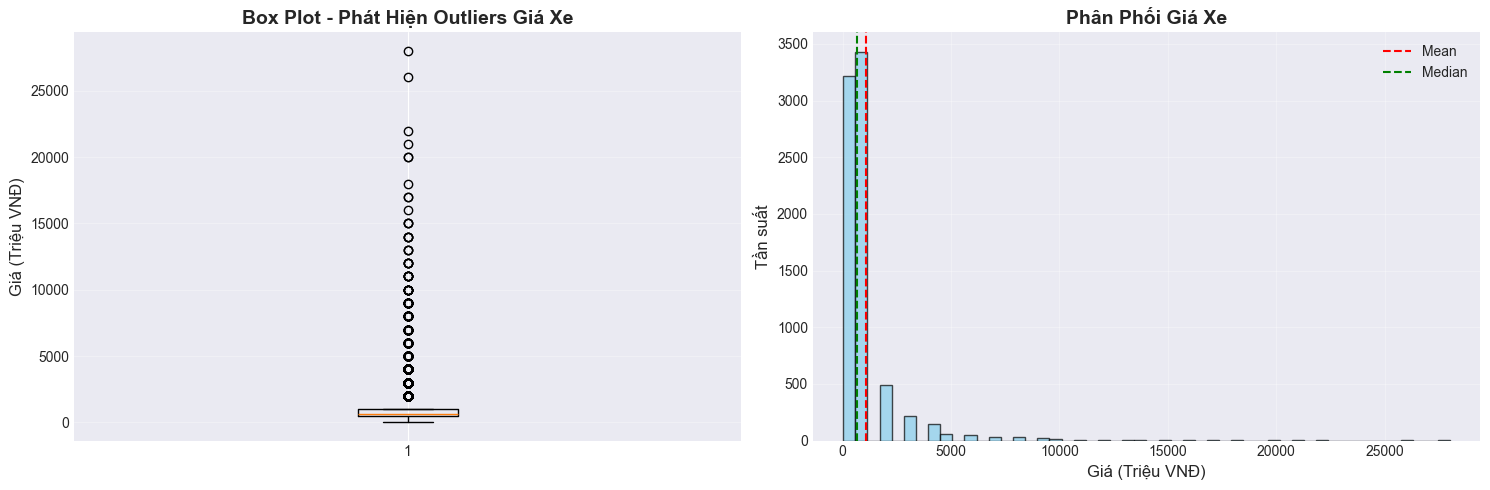

In [31]:
# Visualize outliers cho Giá
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
axes[0].boxplot(df_clean['Giá'].dropna() / 1_000_000, vert=True)
axes[0].set_ylabel('Giá (Triệu VNĐ)', fontsize=12)
axes[0].set_title('Box Plot - Phát Hiện Outliers Giá Xe', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram with normal distribution
axes[1].hist(df_clean['Giá'].dropna() / 1_000_000, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].axvline(df_clean['Giá'].mean() / 1_000_000, color='red', linestyle='--', label='Mean')
axes[1].axvline(df_clean['Giá'].median() / 1_000_000, color='green', linestyle='--', label='Median')
axes[1].set_xlabel('Giá (Triệu VNĐ)', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].set_title('Phân Phối Giá Xe', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
print("="*70)
print("🛣️  PHÂN TÍCH OUTLIERS - SỐ KM")
print("="*70)

outliers_km_iqr, lower_iqr_km, upper_iqr_km = detect_outliers_iqr(df_clean, 'Số km đã đi')
print(f"\nIQR: {len(outliers_km_iqr)} outliers ({len(outliers_km_iqr)/len(df_clean)*100:.2f}%)")
print(f"Ngưỡng: {lower_iqr_km:,.0f} - {upper_iqr_km:,.0f} km")

outliers_km_z, lower_z_km, upper_z_km = detect_outliers_zscore(df_clean, 'Số km đã đi', threshold=3)
print(f"\nZ-score (3σ): {len(outliers_km_z)} outliers ({len(outliers_km_z)/len(df_clean)*100:.2f}%)")
print(f"Ngưỡng: {lower_z_km:,.0f} - {upper_z_km:,.0f} km")

🛣️  PHÂN TÍCH OUTLIERS - SỐ KM

IQR: 98 outliers (1.27%)
Ngưỡng: -98,681 - 179,209 km

Z-score (3σ): 9 outliers (0.12%)
Ngưỡng: -484,762 - 586,021 km


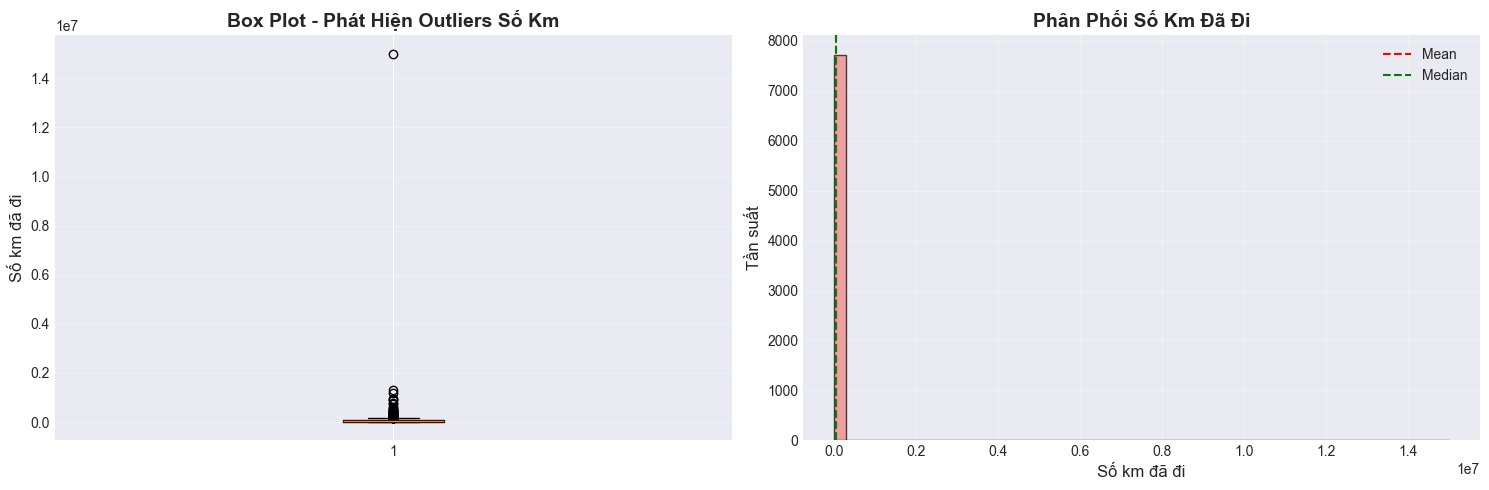

In [33]:
# Visualize outliers cho Số km đã đi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
axes[0].boxplot(df_clean['Số km đã đi'].dropna(), vert=True)
axes[0].set_ylabel('Số km đã đi', fontsize=12)
axes[0].set_title('Box Plot - Phát Hiện Outliers Số Km', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(df_clean['Số km đã đi'].dropna(), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(df_clean['Số km đã đi'].mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(df_clean['Số km đã đi'].median(), color='green', linestyle='--', label='Median')
axes[1].set_xlabel('Số km đã đi', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].set_title('Phân Phối Số Km Đã Đi', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
print("\n🔧 XỬ LÝ OUTLIERS:\n")

high_price_outliers = df_clean[df_clean['Giá'] > upper_iqr]
print(f"💰 Xe giá cao (>{upper_iqr/1_000_000_000:.1f} tỷ): {len(high_price_outliers)}")
if len(high_price_outliers) > 0:
    print(high_price_outliers[['Tên xe', 'Giá', 'Năm SX']].head())


🔧 XỬ LÝ OUTLIERS:

💰 Xe giá cao (>1.8 tỷ): 1094
                                               Tên xe           Giá  Năm SX
1                                    Lexus LX 600 Vip  9.000000e+09    2025
19                                       Lexus RX 350  2.000000e+09    2016
20                                       Lexus LX 570  3.000000e+09    2015
22                                       Lexus LX 570  3.000000e+09    2015
24  LandRover Range Rover Sport Dynamic SE P400 3....  5.000000e+09    2022


In [35]:
print("\n⚙️  Loại bỏ Outliers (1% - 99% percentile)\n")

df_clean_no_outliers = df_clean.copy()

# Xác định ngưỡng outliers
price_lower = df_clean_no_outliers['Giá'].quantile(0.01)
price_upper = df_clean_no_outliers['Giá'].quantile(0.99)

km_lower = df_clean_no_outliers['Số km đã đi'].quantile(0.01)
km_upper = df_clean_no_outliers['Số km đã đi'].quantile(0.99)

print(f"Ngưỡng Giá: {price_lower:,.0f} - {price_upper:,.0f} VNĐ")
print(f"Ngưỡng Số km: {km_lower:,.0f} - {km_upper:,.0f} km")

# Đếm số outliers
price_outliers = df_clean_no_outliers[
    (df_clean_no_outliers['Giá'] < price_lower) | 
    (df_clean_no_outliers['Giá'] > price_upper)
]
km_outliers = df_clean_no_outliers[
    (df_clean_no_outliers['Số km đã đi'] < km_lower) | 
    (df_clean_no_outliers['Số km đã đi'] > km_upper)
]

print(f"\nSố outliers theo giá: {len(price_outliers)}")
print(f"Số outliers theo km: {len(km_outliers)}")

before_count = len(df_clean_no_outliers)

# Loại bỏ outliers
df_clean_no_outliers = df_clean_no_outliers[
    (df_clean_no_outliers['Giá'] >= price_lower) & 
    (df_clean_no_outliers['Giá'] <= price_upper) &
    (df_clean_no_outliers['Số km đã đi'] >= km_lower) & 
    (df_clean_no_outliers['Số km đã đi'] <= km_upper)
]

after_count = len(df_clean_no_outliers)
removed = before_count - after_count

print(f"\n✅ Đã loại bỏ {removed} dòng outliers")
print(f"📊 Còn lại: {after_count} dòng ({after_count/before_count*100:.1f}%)")


⚙️  Loại bỏ Outliers (1% - 99% percentile)

Ngưỡng Giá: 135,000,000 - 8,000,000,000 VNĐ
Ngưỡng Số km: 0 - 190,687 km

Số outliers theo giá: 133
Số outliers theo km: 77

✅ Đã loại bỏ 198 dòng outliers
📊 Còn lại: 7545 dòng (97.4%)


In [36]:
print("\n🔍 XỬ LÝ OUTLIER LOGIC: Xe đã sử dụng có km = 0\n")

# Tìm các xe đã sử dụng nhưng km = 0
logic_outliers = df_clean_no_outliers[
    (df_clean_no_outliers['Tình trạng'] == 'Đã sử dụng') & 
    (df_clean_no_outliers['Số km đã đi'] == 0)
]

print(f"Số xe đã sử dụng có km = 0: {len(logic_outliers)}")

if len(logic_outliers) > 0:
    print("\nCác xe có vấn đề:")
    print(logic_outliers[['Tên xe', 'Năm SX', 'Tình trạng', 'Số km đã đi']].head(10))
    
    # Loại bỏ các dòng không hợp lý
    before_count = len(df_clean_no_outliers)
    df_clean_no_outliers = df_clean_no_outliers[
        ~((df_clean_no_outliers['Tình trạng'] == 'Đã sử dụng') & 
          (df_clean_no_outliers['Số km đã đi'] == 0))
    ]
    after_count = len(df_clean_no_outliers)
    removed = before_count - after_count
    
    print(f"\n✅ Đã loại bỏ {removed} xe không hợp lý")
    print(f"📊 Còn lại: {after_count} dòng")
else:
    print("✅ Không có xe đã sử dụng với km = 0")


🔍 XỬ LÝ OUTLIER LOGIC: Xe đã sử dụng có km = 0

Số xe đã sử dụng có km = 0: 612

Các xe có vấn đề:
                                     Tên xe  Năm SX  Tình trạng  Số km đã đi
40             Mercedes Benz GLC 250 4Matic    2018  Đã sử dụng          0.0
76                Kia Sportage Premium 2.0G    2024  Đã sử dụng          0.0
87                 Kia Cerato 1.6 AT Deluxe    2020  Đã sử dụng          0.0
90                 Kia Morning 1.0 AT Sport    2012  Đã sử dụng          0.0
96           Mercedes Benz C class C300 AMG    2020  Đã sử dụng          0.0
291  Mercedes Benz GLA class GLA 250 4Matic    2019  Đã sử dụng          0.0
336             Mercedes Benz S class S500L    2015  Đã sử dụng          0.0
362                       Toyota Camry 2.5Q    2017  Đã sử dụng          0.0
364             Toyota Fortuner 2.7V 4x2 AT    2015  Đã sử dụng          0.0
367          Mercedes Benz C class C300 AMG    2016  Đã sử dụng          0.0

✅ Đã loại bỏ 612 xe không hợp lý
📊 Còn lại: 6933 dòn

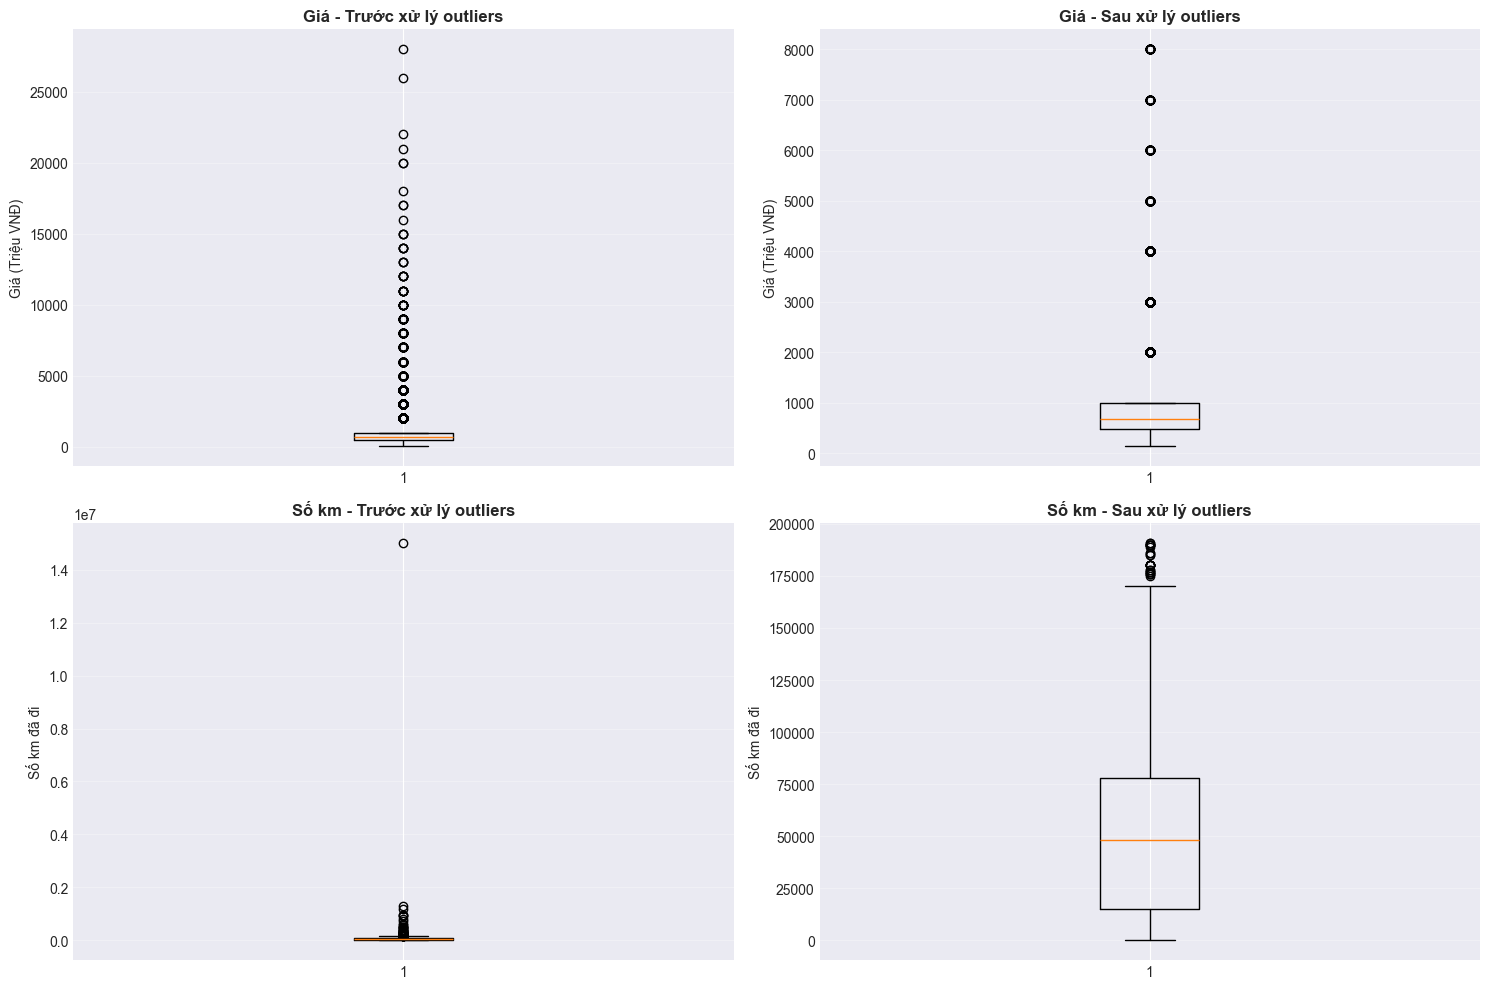

In [37]:
# So sánh trước và sau khi xử lý outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Giá - Trước xử lý
axes[0, 0].boxplot(df_clean['Giá'].dropna() / 1_000_000)
axes[0, 0].set_title('Giá - Trước xử lý outliers', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Giá (Triệu VNĐ)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Giá - Sau xử lý
axes[0, 1].boxplot(df_clean_no_outliers['Giá'].dropna() / 1_000_000)
axes[0, 1].set_title('Giá - Sau xử lý outliers', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Giá (Triệu VNĐ)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Số km - Trước xử lý
axes[1, 0].boxplot(df_clean['Số km đã đi'].dropna())
axes[1, 0].set_title('Số km - Trước xử lý outliers', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Số km đã đi')
axes[1, 0].grid(axis='y', alpha=0.3)

# Số km - Sau xử lý
axes[1, 1].boxplot(df_clean_no_outliers['Số km đã đi'].dropna())
axes[1, 1].set_title('Số km - Sau xử lý outliers', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Số km đã đi')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. LƯU DỮ LIỆU ĐÃ ĐƯỢC LÀM SẠCH

In [38]:
print("💾 LƯU DỮ LIỆU ĐÃ LÀM SẠCH\n")

df_clean.to_csv('bonbanh_data_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"✅ Lưu: bonbanh_data_cleaned.csv ({len(df_clean)} dòng)")

df_clean_no_outliers.to_csv('bonbanh_data_cleaned_no_outliers.csv', index=False, encoding='utf-8-sig')
print(f"✅ Lưu: bonbanh_data_cleaned_no_outliers.csv ({len(df_clean_no_outliers)} dòng)")

💾 LƯU DỮ LIỆU ĐÃ LÀM SẠCH

✅ Lưu: bonbanh_data_cleaned.csv (7743 dòng)
✅ Lưu: bonbanh_data_cleaned_no_outliers.csv (6933 dòng)


## 6. TRỰC QUAN HÓA VÀ PHÂN TÍCH DỮ LIỆU

Sử dụng các kỹ thuật visualization từ bài giảng

In [39]:
print("\n📊 6. TRỰC QUAN HÓA VÀ PHÂN TÍCH DỮ LIỆU\n")
print(f"Số dòng: {len(df_clean)}")
print(f"Phạm vi ngày đăng: {df_clean['Ngày đăng bài'].min()} - {df_clean['Ngày đăng bài'].max()}")


📊 6. TRỰC QUAN HÓA VÀ PHÂN TÍCH DỮ LIỆU

Số dòng: 7743
Phạm vi ngày đăng: 2025-10-23 00:00:00 - 2025-10-23 00:00:00


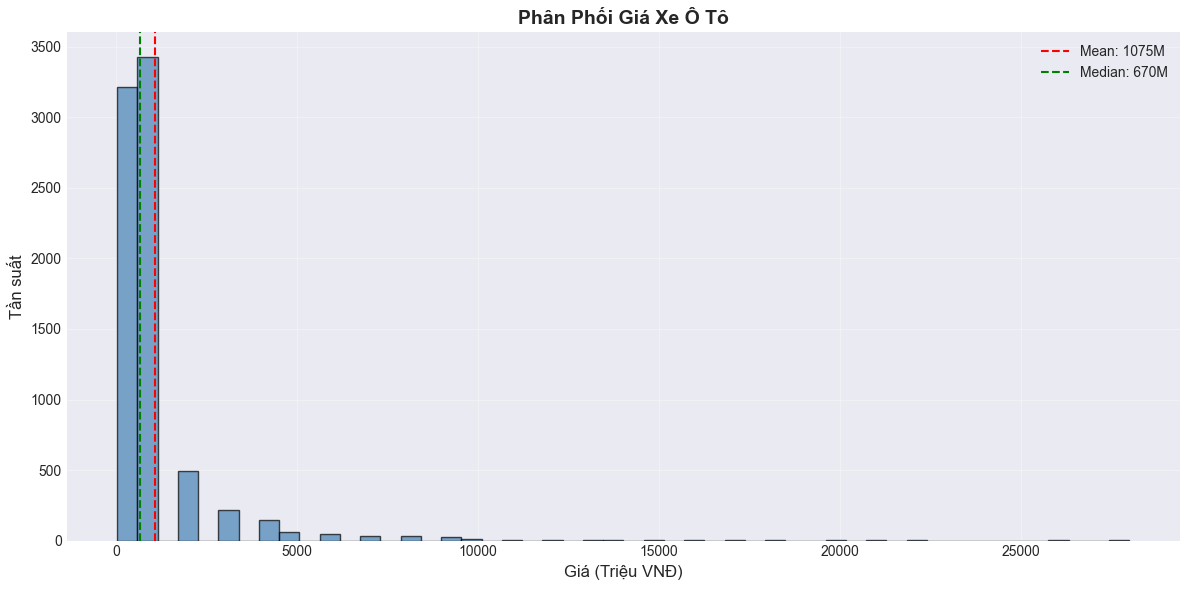

In [40]:
plt.figure(figsize=(12, 6))
plt.hist(df_clean['Giá'] / 1_000_000, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Giá (Triệu VNĐ)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.title('Phân Phối Giá Xe Ô Tô', fontsize=14, fontweight='bold')
plt.axvline(df_clean['Giá'].mean() / 1_000_000, color='red', linestyle='--', 
            label=f'Mean: {df_clean["Giá"].mean() / 1_000_000:.0f}M')
plt.axvline(df_clean['Giá'].median() / 1_000_000, color='green', linestyle='--',
            label=f'Median: {df_clean["Giá"].median() / 1_000_000:.0f}M')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

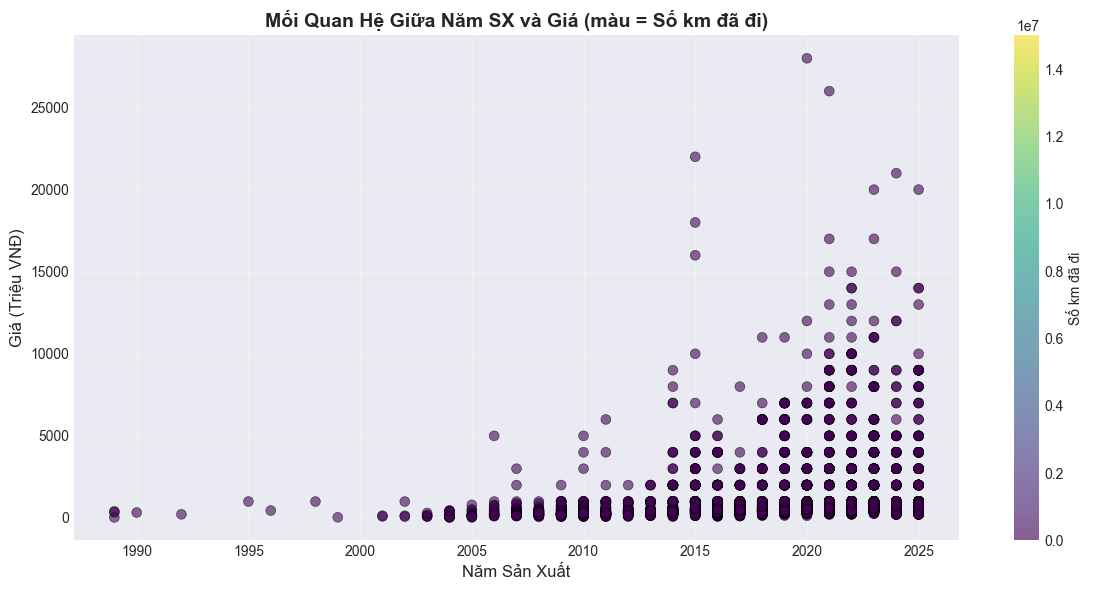

In [41]:
# 6.2. Scatter Plot - Mối quan hệ Năm SX và Giá
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_clean['Năm SX'], df_clean['Giá'] / 1_000_000, 
                     c=df_clean['Số km đã đi'], cmap='viridis', 
                     alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
plt.xlabel('Năm Sản Xuất', fontsize=12)
plt.ylabel('Giá (Triệu VNĐ)', fontsize=12)
plt.title('Mối Quan Hệ Giữa Năm SX và Giá (màu = Số km đã đi)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Số km đã đi')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

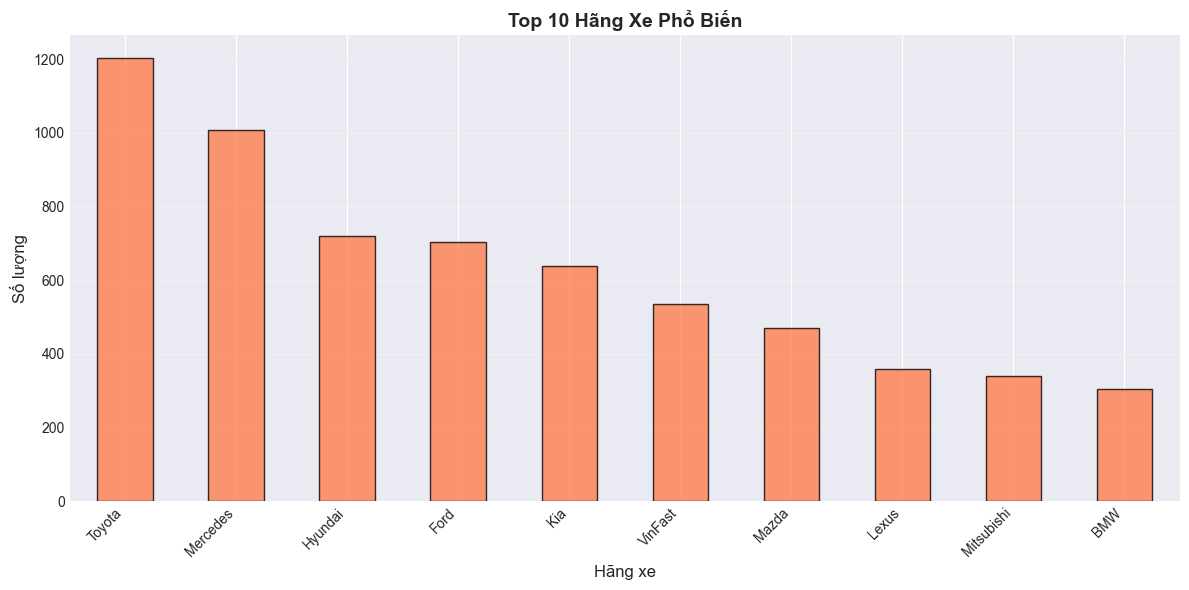

In [42]:
df_clean['Hãng xe'] = df_clean['Tên xe'].str.split().str[0]

top_brands = df_clean['Hãng xe'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_brands.plot(kind='bar', color='coral', edgecolor='black', alpha=0.8)
plt.xlabel('Hãng xe', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.title('Top 10 Hãng Xe Phổ Biến', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

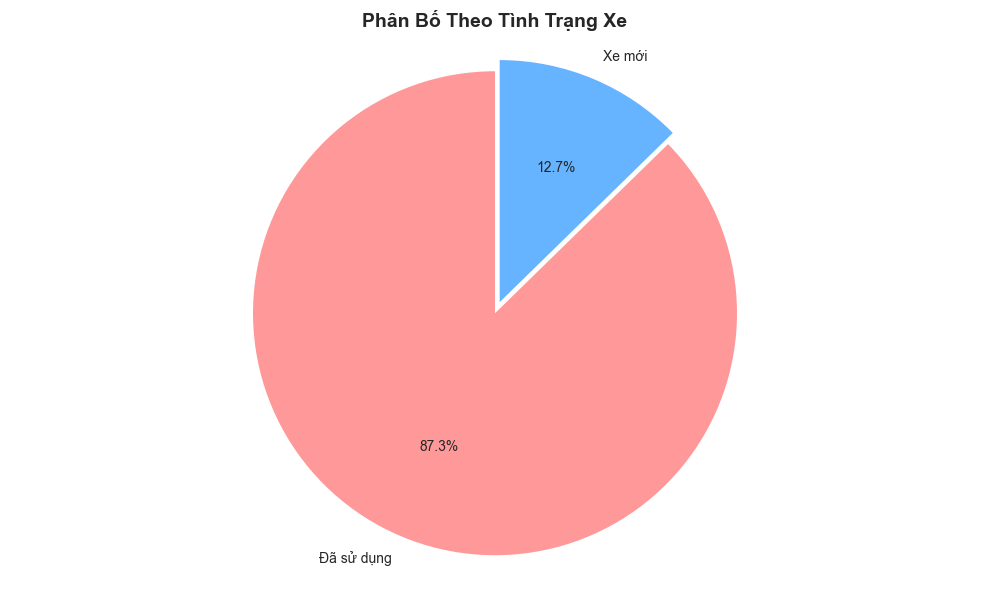

In [43]:
# 6.4. Pie Chart - Phân bố theo tình trạng xe
condition_counts = df_clean['Tình trạng'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(condition_counts, labels=condition_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#ff9999', '#66b3ff'], explode=(0.05, 0))
plt.title('Phân Bố Theo Tình Trạng Xe', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

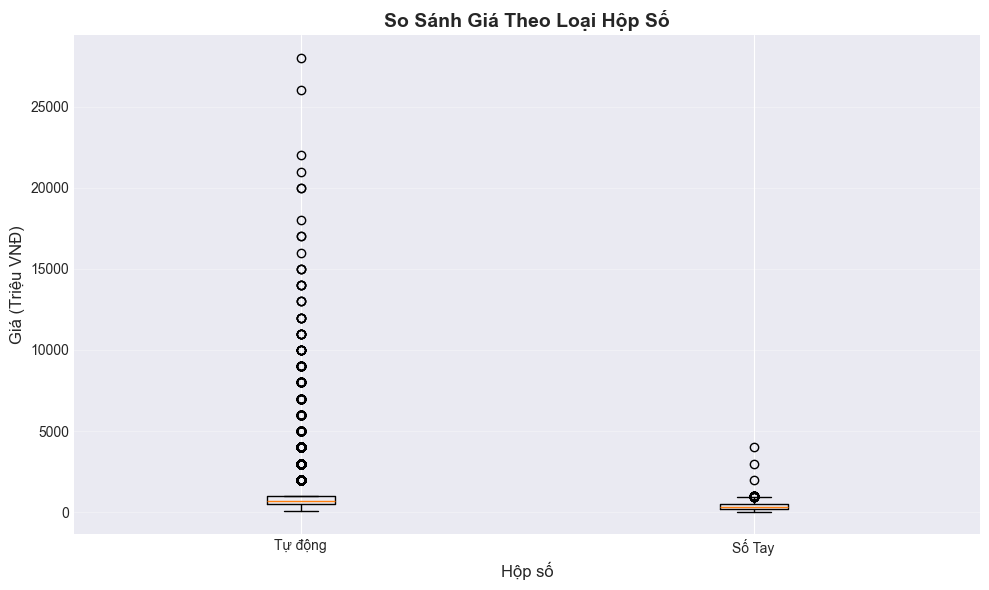

In [44]:
# 6.5. Box Plot - So sánh giá theo hộp số
fig, ax = plt.subplots(figsize=(10, 6))

transmission_data = []
labels = []
for transmission in df_clean['Hộp số'].unique():
    if pd.notna(transmission):
        data = df_clean[df_clean['Hộp số'] == transmission]['Giá'].dropna() / 1_000_000
        if len(data) > 0:
            transmission_data.append(data)
            labels.append(transmission)

ax.boxplot(transmission_data, labels=labels)
ax.set_xlabel('Hộp số', fontsize=12)
ax.set_ylabel('Giá (Triệu VNĐ)', fontsize=12)
ax.set_title('So Sánh Giá Theo Loại Hộp Số', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

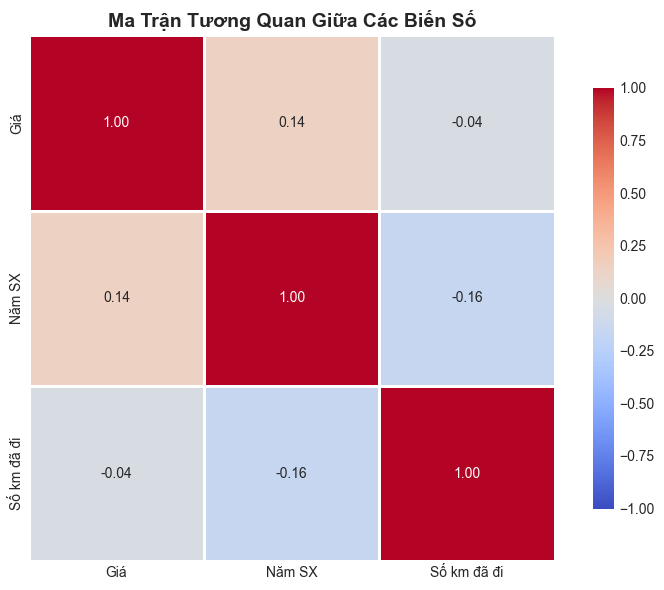


📊 PHÂN TÍCH TƯƠNG QUAN:

                  Giá    Năm SX  Số km đã đi
Giá          1.000000  0.141082    -0.044583
Năm SX       0.141082  1.000000    -0.160360
Số km đã đi -0.044583 -0.160360     1.000000


In [45]:
# 6.6. Heatmap - Correlation matrix cho các biến số
numeric_df = df_clean[['Giá', 'Năm SX', 'Số km đã đi']].copy()
correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', vmin=-1, vmax=1)
plt.title('Ma Trận Tương Quan Giữa Các Biến Số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 PHÂN TÍCH TƯƠNG QUAN:\n")
print(correlation)

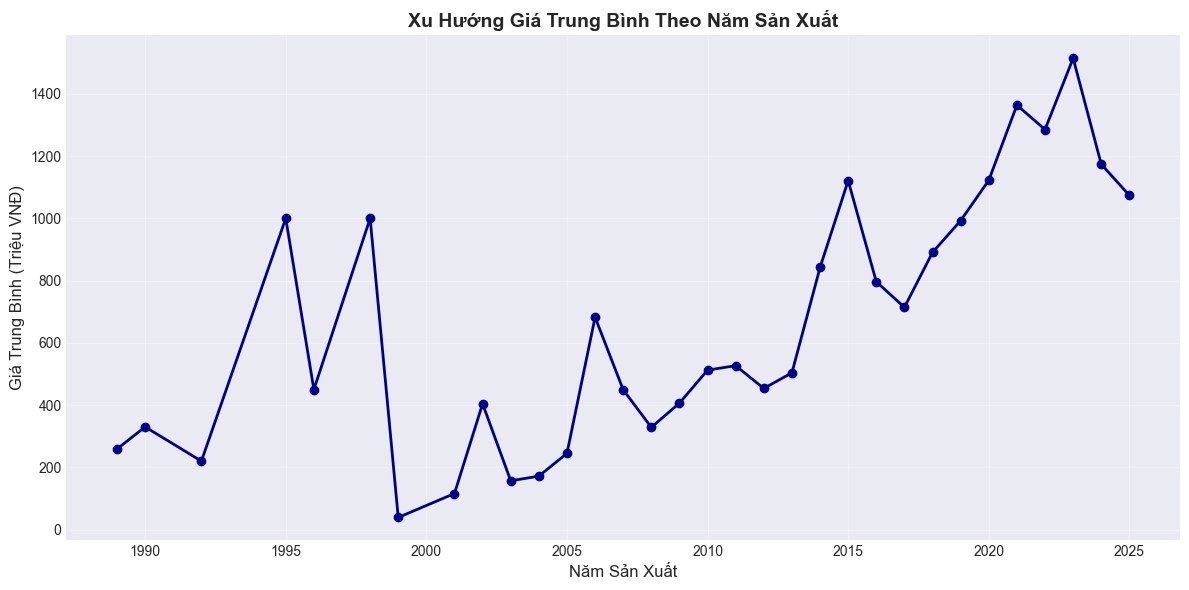

In [46]:
# 6.7. Line Plot - Xu hướng giá trung bình theo năm SX
avg_price_by_year = df_clean.groupby('Năm SX')['Giá'].mean().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(avg_price_by_year.index, avg_price_by_year.values / 1_000_000, 
         marker='o', linewidth=2, markersize=6, color='darkblue')
plt.xlabel('Năm Sản Xuất', fontsize=12)
plt.ylabel('Giá Trung Bình (Triệu VNĐ)', fontsize=12)
plt.title('Xu Hướng Giá Trung Bình Theo Năm Sản Xuất', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

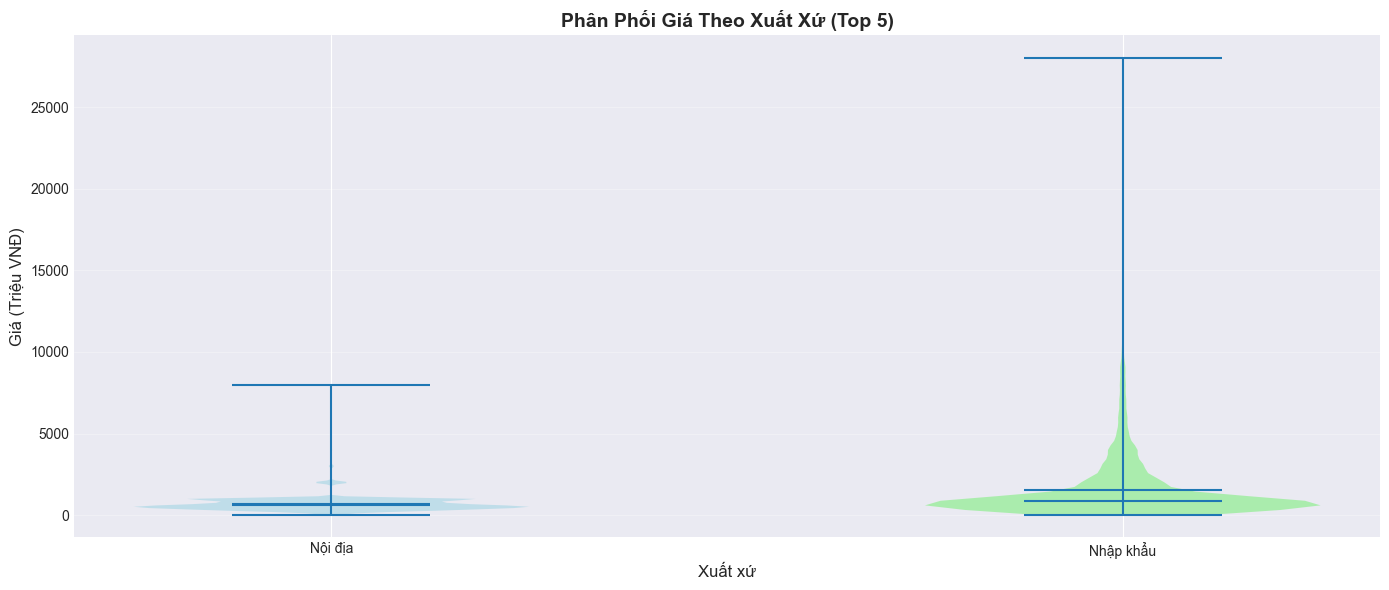

In [47]:
# 6.8. Violin Plot - Phân phối giá theo xuất xứ
plt.figure(figsize=(14, 6))
origins = df_clean['Xuất xứ'].value_counts().head(5).index
data_to_plot = [df_clean[df_clean['Xuất xứ'] == origin]['Giá'].dropna() / 1_000_000 
                for origin in origins]

parts = plt.violinplot(data_to_plot, positions=range(len(origins)), 
                       showmeans=True, showmedians=True)

# Màu sắc cho violin plot
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

plt.xlabel('Xuất xứ', fontsize=12)
plt.ylabel('Giá (Triệu VNĐ)', fontsize=12)
plt.title('Phân Phối Giá Theo Xuất Xứ (Top 5)', fontsize=14, fontweight='bold')
plt.xticks(range(len(origins)), origins)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. TÓM TẮT VÀ KẾT LUẬN

In [48]:
print("\n" + "="*70)
print(" "*20 + "📋 TÓM TẮT BÁO CÁO")
print("="*70)

print("\n🎯 QUY TRÌNH:")
print("   1. ✅ Thu thập dữ liệu từ bonbanh.com")
print("   2. ✅ Hiển thị và khám phá dữ liệu")
print("   3. ✅ Lưu dữ liệu thô")
print("   4. ✅ Làm sạch dữ liệu")
print("   5. ✅ Trực quan hóa và phân tích")

print("\n📊 THỐNG KÊ:")
print(f"   • Tổng số xe: {len(df_clean)}")
print(f"   • Năm SX: {int(df_clean['Năm SX'].min())} - {int(df_clean['Năm SX'].max())}")
print(f"   • Giá TB: {df_clean['Giá'].mean():,.0f} VNĐ")
print(f"   • Giá median: {df_clean['Giá'].median():,.0f} VNĐ")
print(f"   • Số km TB: {df_clean['Số km đã đi'].mean():,.0f} km")
print(f"   • Hãng xe phổ biến: {df_clean['Hãng xe'].mode()[0]}")
print(f"   • Số hãng xe: {df_clean['Hãng xe'].nunique()}")

print("\n📈 KỸ THUẬT:")
print("   • Web Crawling (BeautifulSoup)")
print("   • Missing Value Imputation")
print("   • Outlier Detection (IQR, Z-score)")
print("   • Data Visualization")

print("\n💾 FILES:")
print("   • bonbanh_data_raw.csv")
print("   • bonbanh_data_cleaned.csv")
print("   • bonbanh_data_cleaned_no_outliers.csv")

print("\n" + "="*70)
print(" "*15 + "✅ HOÀN THÀNH")
print("="*70)


                    📋 TÓM TẮT BÁO CÁO

🎯 QUY TRÌNH:
   1. ✅ Thu thập dữ liệu từ bonbanh.com
   2. ✅ Hiển thị và khám phá dữ liệu
   3. ✅ Lưu dữ liệu thô
   4. ✅ Làm sạch dữ liệu
   5. ✅ Trực quan hóa và phân tích

📊 THỐNG KÊ:
   • Tổng số xe: 7743
   • Năm SX: 1989 - 2025
   • Giá TB: 1,074,674,416 VNĐ
   • Giá median: 670,000,000 VNĐ
   • Số km TB: 50,630 km
   • Hãng xe phổ biến: Toyota
   • Số hãng xe: 65

📈 KỸ THUẬT:
   • Web Crawling (BeautifulSoup)
   • Missing Value Imputation
   • Outlier Detection (IQR, Z-score)
   • Data Visualization

💾 FILES:
   • bonbanh_data_raw.csv
   • bonbanh_data_cleaned.csv
   • bonbanh_data_cleaned_no_outliers.csv

               ✅ HOÀN THÀNH
